# Q10. Does a frozen Evo2 7B classifier improve on the 1B BioNeMo configuration?

Compare frozen **7B** and **1B** representations with the same classifier recipe on **3,658 training / 1,342 validation missense SNVs**. Only DNA enters either predictor. [Implementation](src/q10.py) · [GPU worker](src/q10_backend.py) · [Shared dependencies](../requirements.txt).

## Frozen inputs

Reuse [Q1](Q1-clinvar-split.ipynb)’s exact **5 September 2026 ClinVar** pilot and **1,024-base GRCh38 contexts**; reconstruct Q1 automatically if absent. Reject changed VCFs, nonmissense variants, shared genes/loci/IDs, overlapping windows and identical contexts across splits. [Manifest](results/q1/split_manifest.csv) · [Checks](results/q10/input_checks.json).

The comparison uses [Q9](Q9-evo2-1b.ipynb)’s completed 1B baseline. Homology, shared patients and pretraining overlap remain unresolved. The file named `clinvar-test-pilot.vcf` is validation; there is no untouched test.

In [1]:
from src import q10
from threadpoolctl import threadpool_limits
threads = threadpool_limits(limits=4)
_ = q10.prepare_inputs()

Verified 3,658 training / 1,342 validation missense variants.


## BioNeMo 7B

Reuse the shared **Python 3.12 / NVIDIA PyTorch 25.04** runtime and pinned BioNeMo sources in `.venv/q9`; setup is automatic. Download the **15.8 GB** checkpoint and convert to Zarr; allow about **32 GiB additional disk space**. Use **4 CPU threads** and the local **L40S, 48 GB** GPU.

Use [Savanna Evo2 7B base](https://huggingface.co/arcinstitute/savanna_evo2_7b_base/tree/eb0a7478e5f3c291f31e2b3d9ec14fc067f9982a), revision `eb0a7478`, with **BF16**, no FP8, and seed **42**. [NVIDIA documents BF16 support for 7B](https://docs.nvidia.com/bionemo-framework/2.7.1/main/developer-guide/bionemo-evo2/bionemo-evo2-Overview/index.html#available-models-in-ngc). Exact hashes, packages and settings appear below.

In [2]:
_ = q10.establish_environment()

probe: log → notebooks/results/q9/environment/probe.log


Existing BioNeMo environment passed its import and CUDA checks.


## Frozen features

Mean-pool the final block before normalization, average both strands, then concatenate `[reference, alternate − reference]`: **8,192 features**. Check every converted parameter, A/B/A repeatability and strand invariance using training DNA only. Save batches of 100 variants for checked resumption. [Progress log](results/q10/environment/features.log).

In [3]:
_ = q10.extract_features()

features: notebooks/results/q10/environment/features.log


Cached 5,000 variants × 8,192 features; 34.1 min, 12.6 GiB peak GPU memory.


## Classifier and validation

Fit the scaler and balanced L2 logistic regression on **training only**. Select **C ∈ {0.01, 0.1, 1, 10}** by validation AUROC, matching Q9’s objective and C grid. Allow **30,000 LBFGS iterations** and require convergence; the 7B fit exceeded Q9’s 3,000-iteration limit. Compare AUROC and average precision using **1,000 paired component-bootstrap** samples. Validation guides selection; the intervals do not correct that bias.

Verified completed 7B classifier and validation results.


Verified completed 7B classifier and validation results.


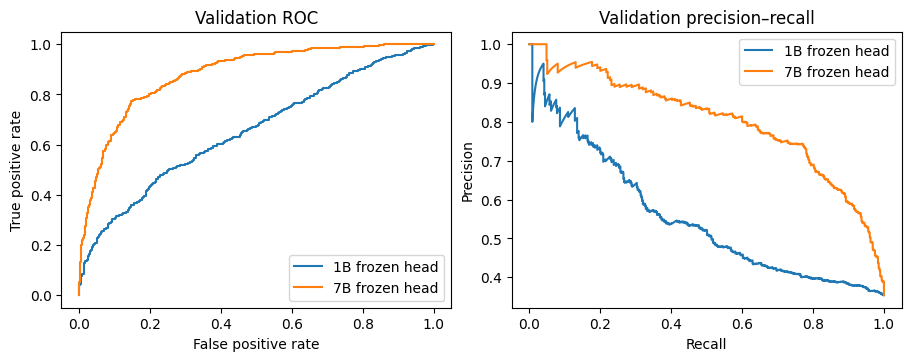

In [4]:
_ = q10.fit_and_evaluate()
q10.show_results()

[Protocol](results/q10/protocol.json) · [Selection](results/q10/selection.json) · [Predictions](results/q10/validation_predictions.csv)

The original 1B checkpoint is BF16-sensitive. A difference therefore compares these configurations and cannot be attributed solely to parameter count.

## Conclusion

In [5]:
q10.show_conclusion()

The frozen **7B** classifier reaches **0.881 AUROC**, a **+0.227** change versus 1B (paired 95% interval [+0.188, +0.269]). This compares the two BioNeMo configurations; the 1B checkpoint’s BF16 sensitivity prevents attributing the difference solely to size. Validation selected C; no untouched test was evaluated.